In [21]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torch import nn, optim

from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
from collections import Counter

In [22]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torch import nn, optim

from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
from collections import Counter

In [23]:
DATA_DIR = "../data"
MODEL_PATH = "../models/waste_model.pth"
CLASS_PATH = "../models/classes.json"
ASSETS_DIR = "../assets"

os.makedirs("../models", exist_ok=True)
os.makedirs(ASSETS_DIR, exist_ok=True)

In [25]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [26]:
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)

class_names = full_dataset.classes
print("Classes:", class_names)

with open(CLASS_PATH, "w") as f:
    json.dump(class_names, f)

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [27]:
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# Fix transforms
val_dataset.dataset.transform = val_test_transforms
test_dataset.dataset.transform = val_test_transforms

print(f"Train: {len(train_dataset)}")
print(f"Val: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Train: 1768
Val: 379
Test: 380


In [35]:
train_targets = [full_dataset.targets[i] for i in train_dataset.indices]

class_sample_count = np.bincount(train_targets)
weights = 1. / class_sample_count

samples_weight = np.array([weights[t] for t in train_targets])
samples_weight = torch.from_numpy(samples_weight).float()

sampler = WeightedRandomSampler(
    samples_weight,
    num_samples=len(samples_weight),
    replacement=True
)

In [36]:
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [37]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Freeze all layers
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.features[-1].parameters():
    param.requires_grad = True

# Replace classifier
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(class_names))

model = model.to(device)

In [38]:
labels = [label for _, label in full_dataset]
class_counts = Counter(labels)

total = sum(class_counts.values())
weights = [total / class_counts[i] for i in range(len(class_names))]

weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(model.parameters(), lr=3e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=2,
    verbose=True
)

In [39]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total

In [40]:
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), correct / total

In [41]:
EPOCHS = 20
best_val_loss = float('inf')
patience = 5
counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        print("✅ Model saved!")
        counter = 0
    else:
        counter += 1
        print(f"⚠️ No improvement ({counter}/{patience})")

        if counter >= patience:
            print("⛔ Early stopping triggered")
            break


Epoch 1/20


100%|██████████| 56/56 [00:05<00:00,  9.41it/s]


Train Loss: 1.2810, Train Acc: 0.4361
Val Loss: 1.1525, Val Acc: 0.5594
✅ Model saved!

Epoch 2/20


100%|██████████| 56/56 [00:04<00:00, 12.67it/s]


Train Loss: 0.7533, Train Acc: 0.6997
Val Loss: 0.8630, Val Acc: 0.6834
✅ Model saved!

Epoch 3/20


...

Train Loss: 0.0978, Train Acc: 0.9689
Val Loss: 0.4162, Val Acc: 0.8681
⚠️ No improvement (1/5)

Epoch 19/20


100%|██████████| 56/56 [00:05<00:00, 10.99it/s]


Train Loss: 0.0985, Train Acc: 0.9655
Val Loss: 0.4144, Val Acc: 0.8734
⚠️ No improvement (2/5)

Epoch 20/20


100%|██████████| 56/56 [00:05<00:00, 10.84it/s]


Train Loss: 0.0743, Train Acc: 0.9825
Val Loss: 0.3876, Val Acc: 0.8760
✅ Model saved!


In [42]:
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

/tmp/ipykernel_1778/3798499344.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH))


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

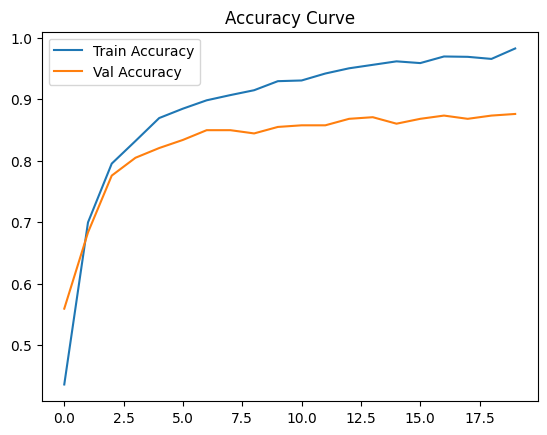

In [43]:
plt.figure()
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.savefig(f"{ASSETS_DIR}/accuracy_curve.png")
plt.show()

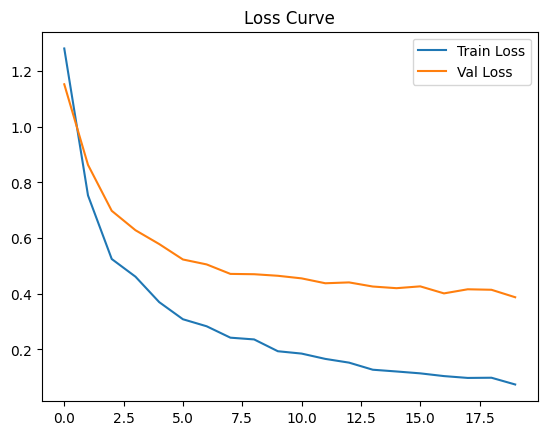

In [44]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.savefig(f"{ASSETS_DIR}/loss_curve.png")
plt.show()

In [45]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [46]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       0.93      0.94      0.94        72
       glass       0.84      0.83      0.83        94
       metal       0.84      0.78      0.81        59
       paper       0.92      0.88      0.90        81
     plastic       0.79      0.87      0.83        61
       trash       0.67      0.77      0.71        13

    accuracy                           0.86       380
   macro avg       0.83      0.84      0.84       380
weighted avg       0.86      0.86      0.86       380



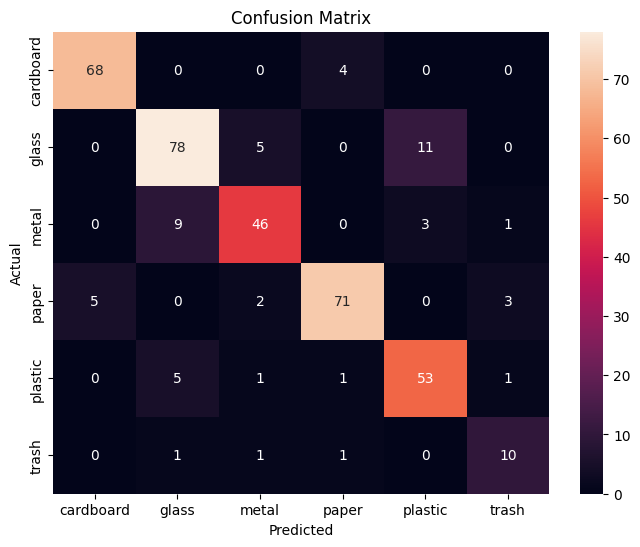

In [47]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(f"{ASSETS_DIR}/confusion_matrix.png")
plt.show()

In [48]:
test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8579
